<a href="https://colab.research.google.com/github/annatagus/python_aulas_exercicios/blob/main/2_M1_Exercicios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Abaixo encontra a resolução de todos os exercícios da folha de **Visualização de Dados (Módulo 1)**, desenvolvida em Python para nível *beginner* com `matplotlib`, `seaborn` e `pandas`, incluindo títulos, rótulos e os comentários/interpretações visuais solicitados.

---

## Preparação e Carregamento do Dataset

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configuração de estilo dos gráficos
sns.set_theme(style="whitegrid")

# Carregar o dataset Penguins
df_penguins = sns.load_dataset("penguins")

---

## GRUPO A: Matplotlib e Tipo de Gráfico

### Exercício 1. Fundamentos e Escolha do Gráfico

#### 1. Tipos de Variáveis e Gráfico Univariado Adequado

* **`species`**: Categórica Nominal $\rightarrow$ Gráfico de Barras / Contagem (`countplot`).
* **`island`**: Categórica Nominal $\rightarrow$ Gráfico de Barras / Contagem (`countplot`).
* **`bill_length_mm`**: Numérica Contínua $\rightarrow$ Histograma / KDE / Boxplot.
* **`bill_depth_mm`**: Numérica Contínua $\rightarrow$ Histograma / KDE / Boxplot.
* **`flipper_length_mm`**: Numérica Contínua $\rightarrow$ Histograma / KDE / Boxplot.
* **`body_mass_g`**: Numérica Contínua $\rightarrow$ Histograma / KDE / Boxplot.
* **`sex`**: Categórica Binária $\rightarrow$ Gráfico de Barras / Contagem (`countplot`).

#### 2. Subplots com 2 Histogramas lado a lado

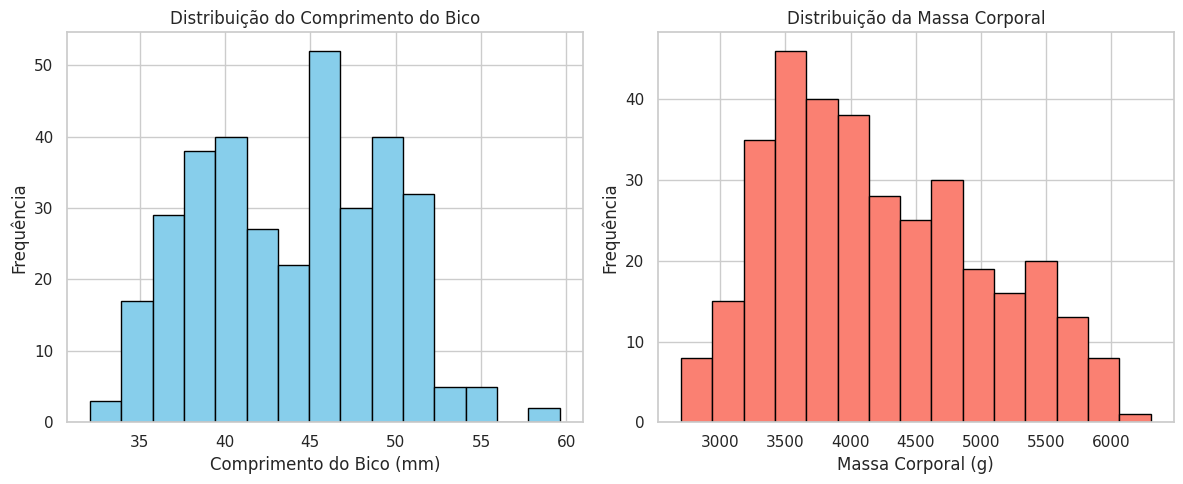

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histograma 1: Comprimento do Bico (bill_length_mm)
axes[0].hist(
    df_penguins["bill_length_mm"].dropna(),
    bins=15,
    color="skyblue",
    edgecolor="black",
)
axes[0].set_title(
    "Distribuição do Comprimento do Bico"
)
axes[0].set_xlabel("Comprimento do Bico (mm)")
axes[0].set_ylabel("Frequência")

# Histograma 2: Massa Corporal (body_mass_g)
axes[1].hist(
    df_penguins["body_mass_g"].dropna(),
    bins=15,
    color="salmon",
    edgecolor="black",
)
axes[1].set_title("Distribuição da Massa Corporal")
axes[1].set_xlabel("Massa Corporal (g)")
axes[1].set_ylabel("Frequência")

plt.tight_layout()
plt.show()

#### 3. Ajuste do Número de Bins e Comentário

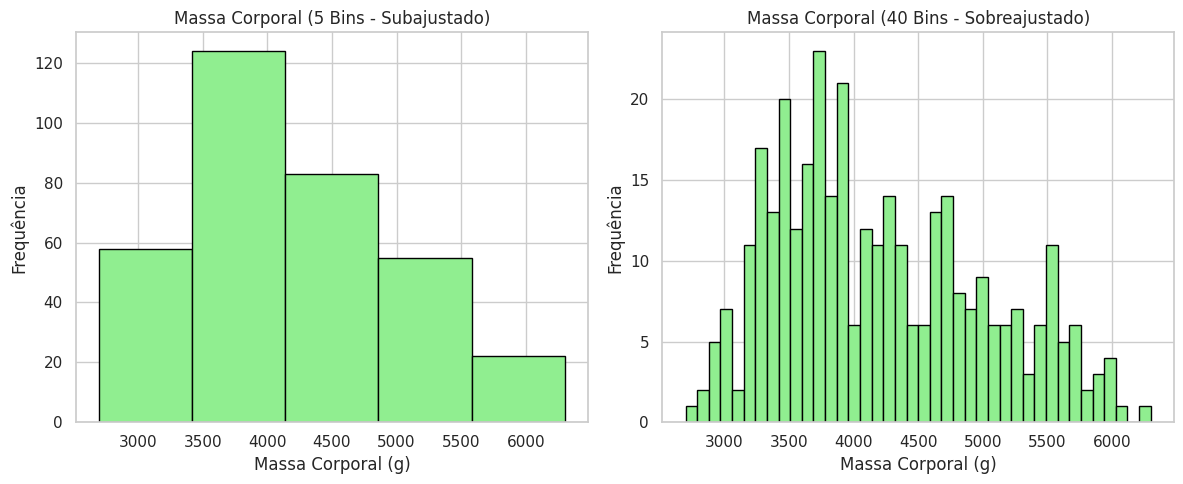

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histograma com poucos Bins (pouco detalhe)
axes[0].hist(
    df_penguins["body_mass_g"].dropna(),
    bins=5,
    color="lightgreen",
    edgecolor="black",
)
axes[0].set_title("Massa Corporal (5 Bins - Subajustado)")
axes[0].set_xlabel("Massa Corporal (g)")
axes[0].set_ylabel("Frequência")

# Histograma com muitos Bins (muito ruído)
axes[1].hist(
    df_penguins["body_mass_g"].dropna(),
    bins=40,
    color="lightgreen",
    edgecolor="black",
)
axes[1].set_title("Massa Corporal (40 Bins - Sobreajustado)")
axes[1].set_xlabel("Massa Corporal (g)")
axes[1].set_ylabel("Frequência")

plt.tight_layout()
plt.show()

# COMENTÁRIO SOBRE O EFEITO DOS BINS:
# - Com poucos bins (ex: 5), a distribuição fica demasiado agregada, escondendo detalhes e possíveis picos secundários.
# - Com demasiados bins (ex: 40), o gráfico ganha demasiado ruído e lacunas, dificultando a perceção da tendência geral.
# - O valor ideal de bins (15 a 20) permite identificar que a distribuição da massa corporal tem uma assimetria à direita com dois picos ligeiros (multimodal).

---

## GRUPO B: Gráficos Essenciais (Seaborn)

### Exercício 2. Scatter e Histograma

#### 1. Scatter Plot: `bill_length_mm` vs `bill_depth_mm` por `species`

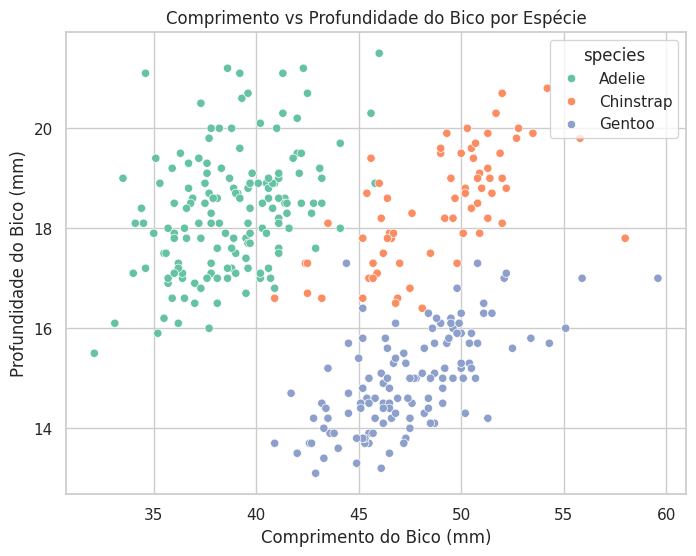

In [16]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_penguins,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species",
    palette="Set2",
)

plt.title(
    "Comprimento vs Profundidade do Bico por Espécie"
)
plt.xlabel("Comprimento do Bico (mm)")
plt.ylabel("Profundidade do Bico (mm)")
plt.show()

# RESPOSTA:
# A espécie 'Adelie' separa-se muito bem das restantes por apresentar bicos mais curtos e profundos
# (valores elevados de bill_depth_mm e baixos de bill_length_mm).

#### 2. Histograma + KDE de `flipper_length_mm` (Geral e com `hue=species`)

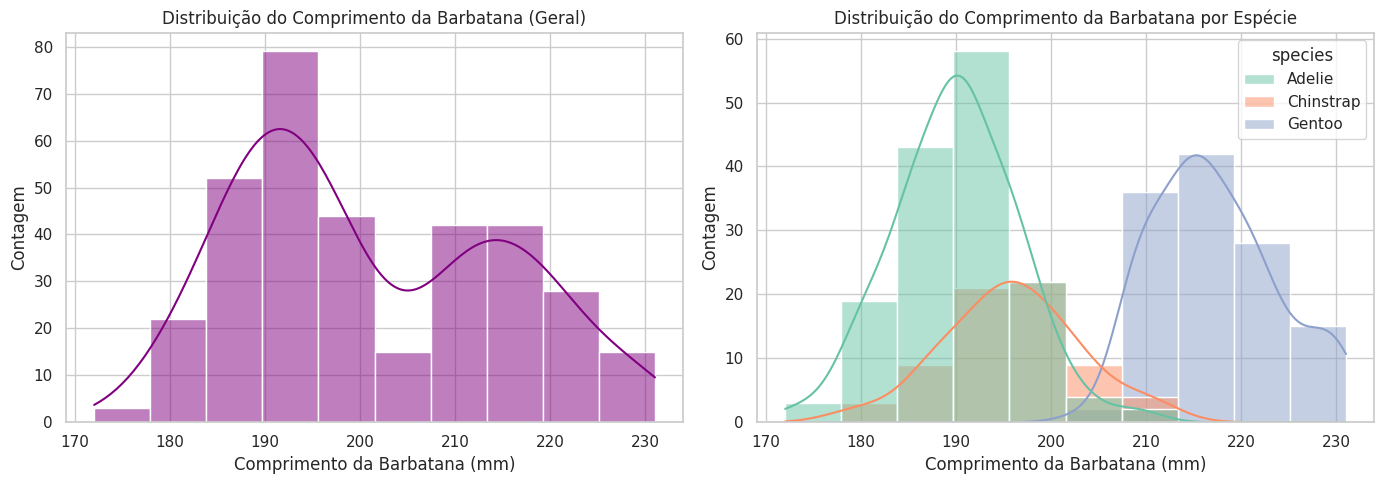

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma Geral com KDE
sns.histplot(
    data=df_penguins,
    x="flipper_length_mm",
    kde=True,
    ax=axes[0],
    color="purple",
)
axes[0].set_title("Distribuição do Comprimento da Barbatana (Geral)")
axes[0].set_xlabel("Comprimento da Barbatana (mm)")
axes[0].set_ylabel("Contagem")

# Histograma por Espécie
sns.histplot(
    data=df_penguins,
    x="flipper_length_mm",
    kde=True,
    hue="species",
    ax=axes[1],
    palette="Set2",
)
axes[1].set_title("Distribuição do Comprimento da Barbatana por Espécie")
axes[1].set_xlabel("Comprimento da Barbatana (mm)")
axes[1].set_ylabel("Contagem")

plt.tight_layout()
plt.show()

# RESPOSTA:
# O gráfico geral é claramente MULTIMODAL (apresenta dois picos distintos: um em torno dos 190mm e outro nos 215mm).
# Ao aplicar hue=species, percebe-se que a bimodalidade existe porque os pinguins Gentoo possuem barbatanas consideravelmente maiores que as espécies Adelie e Chinstrap.

#### 3. Par de Variáveis que Melhor Separa as Espécies

> **Comentário:**
> O par **`flipper_length_mm` e `bill_depth_mm**` (ou `bill_length_mm` vs `bill_depth_mm`) é o que melhor separa as três espécies em aglomerados (*clusters*) bem definidos sem quase nenhuma sobreposição.
>
>

---

### Exercício 3. Boxplot, Barras e Linha

#### 1. Boxplot de `body_mass_g` por `species` (Outliers)

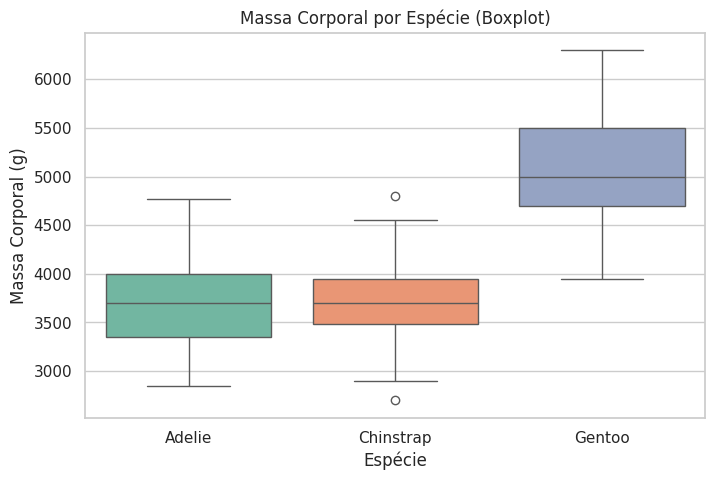

In [21]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_penguins, x="species", y="body_mass_g", palette="Set2", hue="species", legend=False
)

plt.title("Massa Corporal por Espécie (Boxplot)")
plt.xlabel("Espécie")
plt.ylabel("Massa Corporal (g)")
plt.show()

# ANÁLISE DE OUTLIERS:
# Visualmente, observam-se pouquíssimos outliers extremos fora dos "bigodes" (whiskers).
# A espécie Gentoo apresenta uma mediana de massa corporal muito superior (em torno dos 5000g) em relação a Adelie e Chinstrap (em torno dos 3700g).

#### 2. Violinplot de `body_mass_g` por `sex`

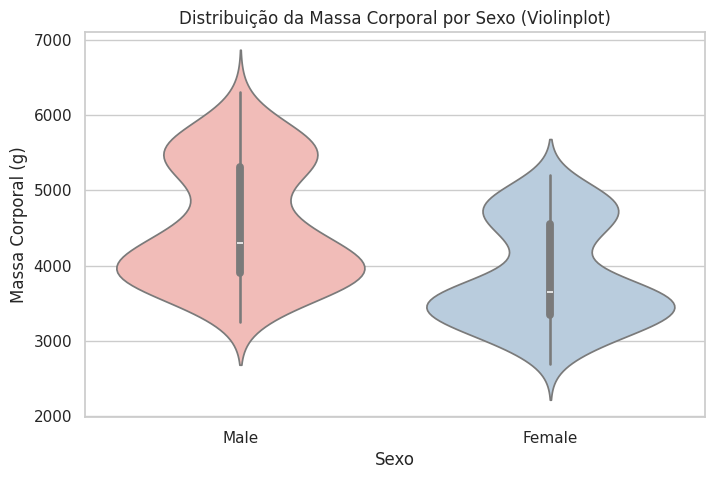

In [22]:
plt.figure(figsize=(8, 5))
sns.violinplot(
    data=df_penguins.dropna(subset=["sex"]),
    x="sex",
    y="body_mass_g",
    hue="sex",
    palette="Pastel1",
    legend=False,
)

plt.title("Distribuição da Massa Corporal por Sexo (Violinplot)")
plt.xlabel("Sexo")
plt.ylabel("Massa Corporal (g)")
plt.show()

# COMPARATIVO DE DISTRIBUIÇÃO:
# Ambos os sexos apresentam distribuições com formato semelhante, mas a distribuição dos Machos (Male)
# está deslocada para cima no eixo Y em relação às Fêmeas (Female), confirmando dimorfismo sexual de tamanho.

#### 3. Bar Chart da Massa Média por `species` e `hue=sex`

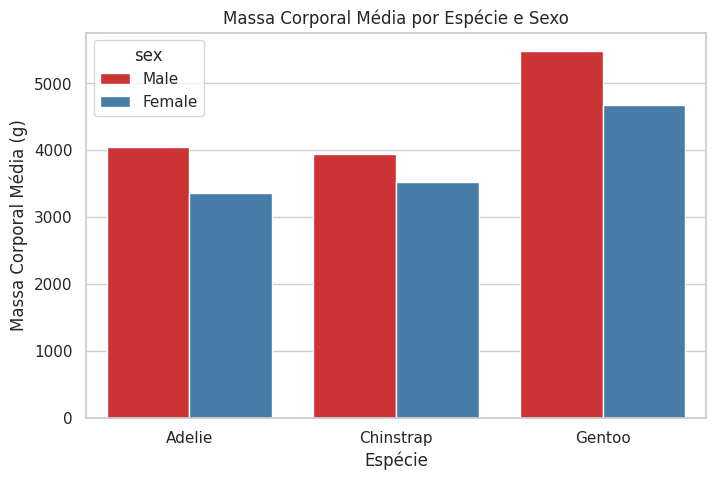

In [23]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=df_penguins.dropna(subset=["sex"]),
    x="species",
    y="body_mass_g",
    hue="sex",
    palette="Set1",
    errorbar=None,
)

plt.title("Massa Corporal Média por Espécie e Sexo")
plt.xlabel("Espécie")
plt.ylabel("Massa Corporal Média (g)")
plt.show()

#### 4. Variable Ordenada e Line Chart (Contagem por Faixa)

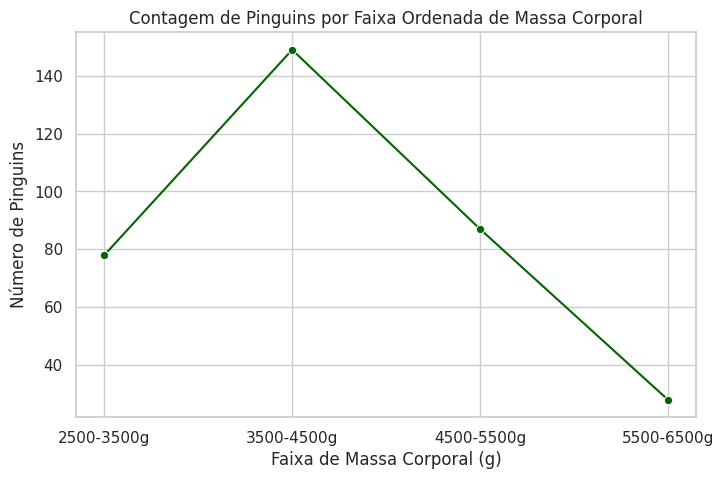

In [24]:
# Criar faixas de massa corporal ordenadas usando pd.cut
df_clean = df_penguins.dropna(subset=["body_mass_g"]).copy()
df_clean["faixa_massa"] = pd.cut(
    df_clean["body_mass_g"],
    bins=[2500, 3500, 4500, 5500, 6500],
    labels=["2500-3500g", "3500-4500g", "4500-5500g", "5500-6500g"],
    ordered=True,
)

# Contagem por faixa ordenada
contagem_faixas = (
    df_clean["faixa_massa"].value_counts().sort_index().reset_index()
)
contagem_faixas.columns = ["faixa_massa", "contagem"]

# Line Chart
plt.figure(figsize=(8, 5))
sns.lineplot(
    data=contagem_faixas, x="faixa_massa", y="contagem", marker="o", color="darkgreen"
)

plt.title("Contagem de Pinguins por Faixa Ordenada de Massa Corporal")
plt.xlabel("Faixa de Massa Corporal (g)")
plt.ylabel("Número de Pinguins")
plt.show()

# NOTA SOBRE O LINE CHART:
# Faz sentido usar o gráfico de linhas aqui porque o eixo X tem uma ordem natural e sequencial (faixas crescentes de peso).

---

## GRUPO C: Multivariada Visual

### Exercício 4. Pairplot e Heatmaps

#### 1. Pairplot das Variáveis Numéricas por Espécie

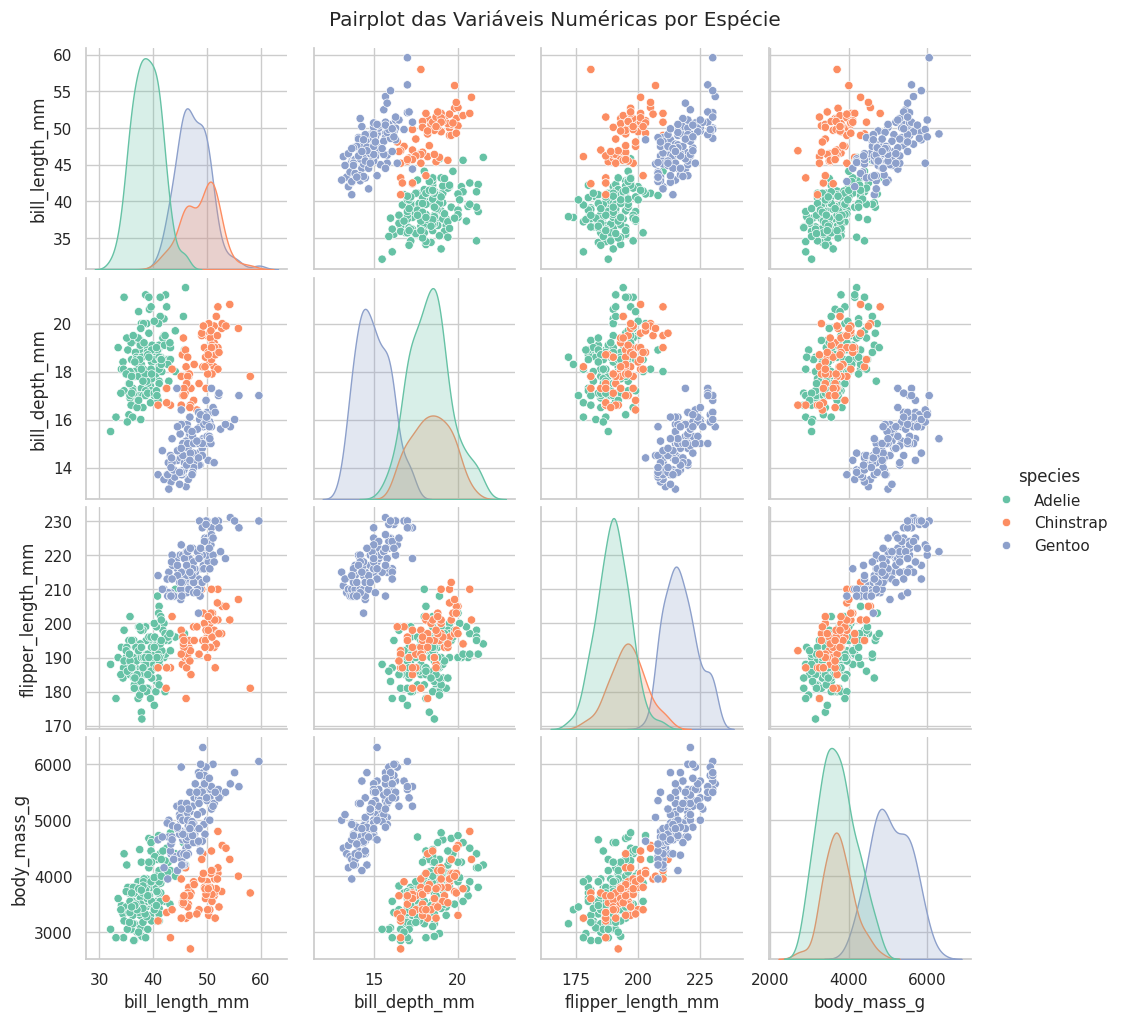

In [10]:
sns.pairplot(
    df_penguins,
    hue="species",
    palette="Set2",
    corner=False,
)

plt.suptitle("Pairplot das Variáveis Numéricas por Espécie", y=1.02)
plt.show()

#### 2. Heatmap da Matriz de Correlação das Numéricas

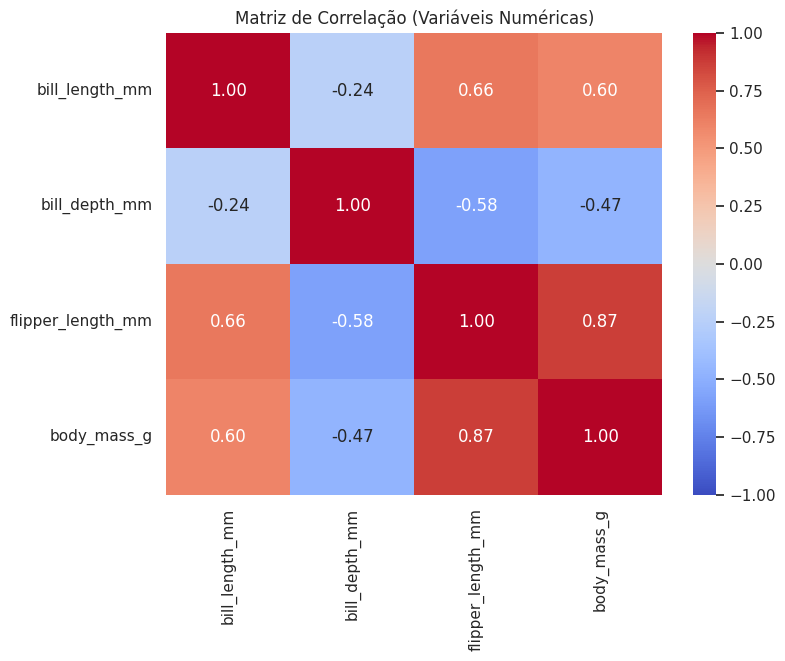

In [11]:
plt.figure(figsize=(8, 6))

# Selecionar apenas colunas numéricas
df_numeric = df_penguins.select_dtypes(include=[np.number])
matriz_corr = df_numeric.corr()

sns.heatmap(matriz_corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Matriz de Correlação (Variáveis Numéricas)")
plt.show()

# PARES MAIS CORRELACIONADOS:
# - Existe uma forte correlação positiva entre 'body_mass_g' e 'flipper_length_mm' (r ≈ 0.87).
# - O comprimento do bico (bill_length_mm) também tem correlação positiva moderada/forte com a massa corporal e barbatana.

#### 3. Heatmap dos Valores Nulos do Dataset

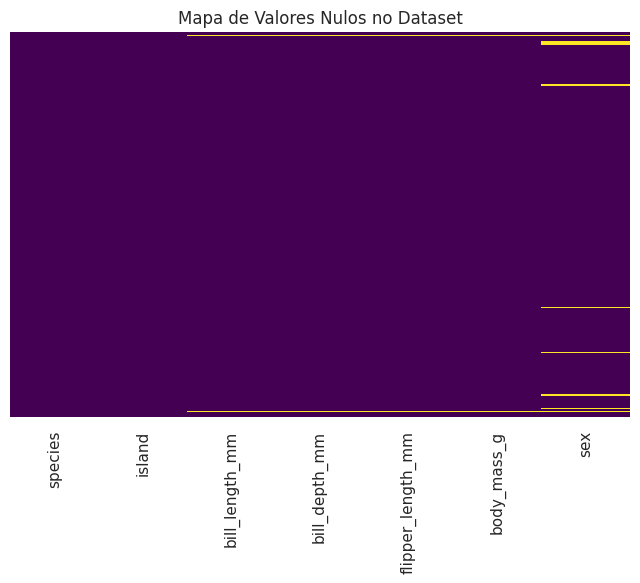

In [12]:
plt.figure(figsize=(8, 5))
sns.heatmap(
    df_penguins.isnull(), cbar=False, cmap="viridis", yticklabels=False
)

plt.title("Mapa de Valores Nulos no Dataset")
plt.show()

# ONDE FALTAM DADOS:
# Faltam dados maioritariamente nas variáveis 'sex' e em algumas poucas linhas das medições do bico/barbatana/massa corporal.

#### 4. Três Conclusões Visuais Fundamentadas

1. **Separação das Espécies**: A espécie **Gentoo** distingue-se claramente das restantes por apresentar maior massa corporal e barbatanas mais compridas, enquanto a espécie **Adelie** separa-se de **Chinstrap** pela profundidade do bico (`bill_depth_mm` mais pronunciado na Adelie e `bill_length_mm` mais longo na Chinstrap).


2. **Redundâncias**: Existe uma forte redundância linear entre a **massa corporal (`body_mass_g`)** e o **comprimento da barbatana (`flipper_length_mm`)** ($r \approx 0.87$), o que sugere que ambas medem essencialmente o tamanho geral do animal.


3. **Dados em Falta**: Os dados em falta estão concentrados no atributo categórico **`sex`** (onde faltam cerca de 11 registos) e num par de registos onde falharam todas as medições físicas simultaneamente.